In [1]:
# Importación de librerías
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
df_unido = pd.read_csv("files/unido.csv", index_col=0)

In [4]:
df_unido.head(2)

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,status_client,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo,2017,1,0,0,0,0,0.0,0,0
1,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo,2017,2,3,0,3,2823,282.0,0,0


# Fase 2: Analisis estadistico

## 2.1 Analisis de variables numéricas
- Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables
numéricas relevantes.
- Identificación de valores atípicos en las variables numéricas.
- Análisis de correlación entre variables numéricas.

In [5]:
df_unido.describe().T

,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
salary,301500.0,79371.732902,34726.433958,9081.00,59262.00,73479.00,88606.00,407228.00
clv,403760.0,7990.864857,6863.317160,1898.01,3981.78,5776.34,8937.12,83325.38
enrollment_year,403760.0,2015.250716,1.979427,2012.00,2014.00,2015.00,2017.00,2018.00
enrollment_month,403760.0,6.667555,3.398829,1.00,4.00,7.00,10.00,12.00
year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
flights_booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
flights_with_companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
total_flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00


Se interpreta lo siguiente:

- **salary**: Hay bastante diferencia entre los valores normales y el máximo. La mayoría de personas tiene sueldos moderados, pero hay algunos casos con sueldos muy altos que destacan mucho (valores atípicos).

- **clv (Customer Lifetime Value)**: Pasa algo parecido al salario. La mayoría de clientes tiene un valor medio, pero hay algunos clientes que generan muchísimo más valor que el resto (clientes “top”).

- **flights_booked**: La mayoría de clientes reserva pocos vuelos (la mediana es 1), pero algunos reservan muchos, lo que hace que la media suba. Esto indica que hay valores extremos.

- **total_flights**: Igual que en la variable anterior, la mayoría vuela poco, pero hay unos pocos que vuelan mucho, generando una distribución desigual.

- **distance**: La mayoría de los viajes son de distancia moderada, pero hay algunos viajes muy largos que se salen de lo normal.

- **points_accumulated**: La mayoría acumula pocos puntos, pero algunos clientes acumulan muchos más, lo que crea diferencias grandes dentro de la variable.

- **points_redeemed**: Aquí se ve claramente que la mayoría de los clientes no usa sus puntos (muchos ceros), pero unos pocos sí hacen canjes altos.

- **dollar_cost_points_redeemed**: Igual que la anterior, casi todos los valores son 0, pero hay algunos casos donde se canjean muchos puntos, lo que genera valores extremos.

- El máximo es exagerado
- Hay mucha diferencia con el 75%
- La media es mayor que la mediana
- En el boxplot salen puntitos fuera

<Axes: xlabel='salary'>

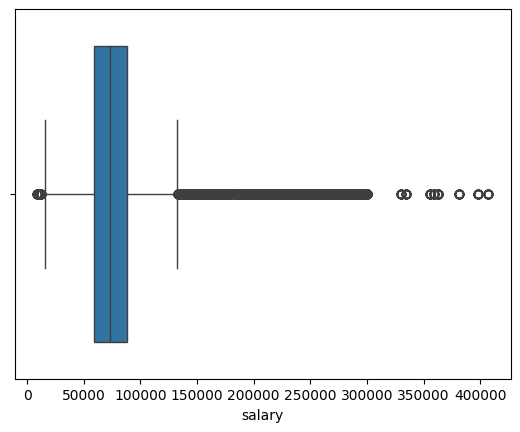

In [6]:
sns.boxplot(data=df_unido, x="salary")

En este gráfico se observa que la mayoría de los salarios se concentran en valores medios (aproximadamente entre 50k y 90k), con una mediana alrededor de 70k. Sin embargo, aparecen muchos puntos a la derecha del gráfico, lo que indica la presencia de personas con salarios muy altos en comparación con la mayoría. Esto muestra una gran cantidad de valores atípicos y una distribución muy desigual.


<Axes: xlabel='clv'>

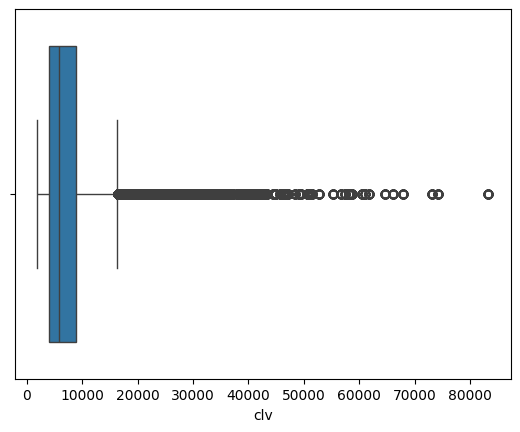

In [7]:
sns.boxplot(data=df_unido, x="clv")

En este gráfico la mayor parte de los clientes tiene un valor moderado (entre unos 4k y 9k aproximadamente), con una mediana cercana a 6k. No obstante, se observan numerosos puntos alejados hacia la derecha, lo que indica que existen clientes con un valor mucho mayor que el resto. Estos representan casos excepcionales o clientes de alto valor, generando también una distribución sesgada.


<Axes: xlabel='distance'>

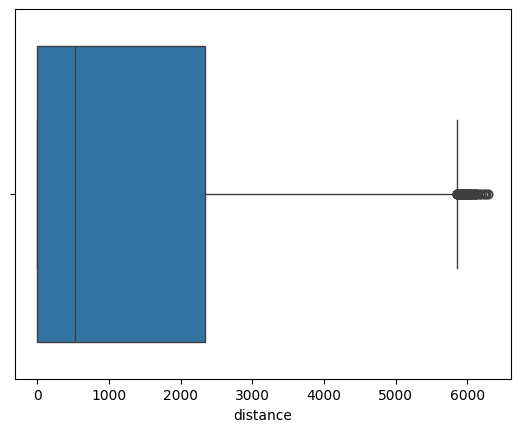

In [8]:
sns.boxplot(data=df_unido, x="distance")

En este gráfico la mayoría de los valores se concentra en distancias bajas o medias, con una mediana relativamente pequeña. Sin embargo, se observan algunos puntos alejados hacia valores altos (alrededor de 6000), lo que indica la existencia de viajes muy largos que no son comunes. En este caso, hay valores atípicos, aunque en menor cantidad que en las variables anteriores.

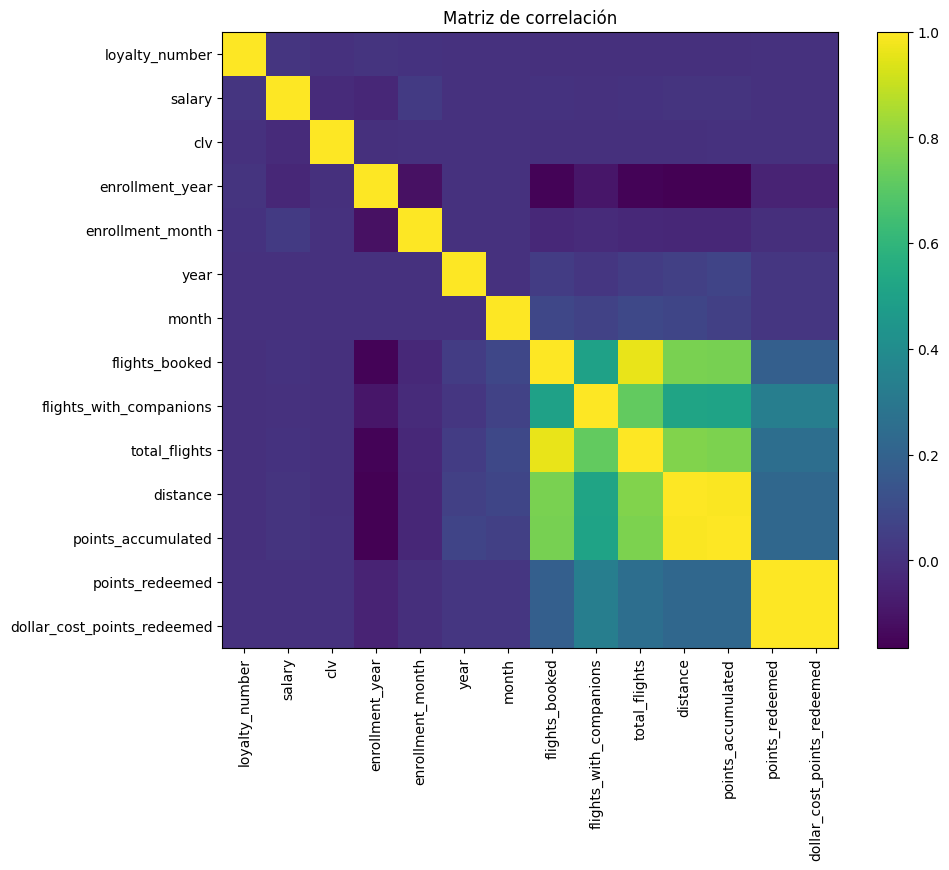

In [9]:
# Matriz de correlación
corr = df_unido.select_dtypes(include='number').corr()

# Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Matriz de correlación")
plt.show()

A partir del heatmap de correlación, se observan las siguientes relaciones entre las variables numéricas:

- Existe una **fuerte correlación positiva** entre *flights_booked* y *total_flights*, lo cual es lógico, ya que ambas variables representan la actividad de vuelo de los clientes.

- También se observa una **alta correlación positiva** entre *distance* y *points_accumulated*, indicando que a mayor distancia recorrida, mayor es la acumulación de puntos.

- Las variables *total_flights*, *distance* y *points_accumulated* están moderadamente correlacionadas entre sí, lo que refleja que los clientes más activos generan más valor.

- *flights_with_companions* presenta correlación positiva con las variables de vuelos, aunque de menor intensidad.

- *points_redeemed* y *dollar_cost_points_redeemed* muestran correlación entre sí, como es esperable, pero tienen **baja relación con el resto de variables**, lo que sugiere que el canje de puntos no depende directamente del nivel de actividad.

- Variables como *salary* y *clv* presentan **baja correlación con la mayoría de variables**, lo que indica que el valor del cliente y sus ingresos no están fuertemente ligados al comportamiento de vuelo en este dataset.

- Las variables temporales (*year*, *month*, *enrollment_year*, *enrollment_month*) muestran correlaciones muy bajas, por lo que no parecen influir significativamente en las demás variables.


# 2.2 Analisis de variables categoricas

In [ ]:
df_cat = df_unido.select_dtypes(include='object')
df_cat.head()

C:\Users\Personal\AppData\Local\Temp\ipykernel_22384\3132003680.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_cat = df_unido.select_dtypes(include='object')


,province,city,postal_code,gender,education,marital_status,loyalty_card,enrollment_type,status_client
0,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,Standard,Activo
1,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,Standard,Activo
2,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,Standard,Activo
3,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,Standard,Activo
4,Ontario,Toronto,M2Z 4K1,Female,Bachelor,Married,Star,Standard,Activo


In [20]:
df_cat.columns

Index(['province', 'city', 'postal_code', 'gender', 'education',
       'marital_status', 'loyalty_card', 'enrollment_type', 'status_client'],
      dtype='str')

In [24]:
df_cat["gender"].value_counts(normalize=True) * 100

gender
Female    50.217208
Male      49.782792
Name: proportion, dtype: float64

In [36]:
df_cat["province"].value_counts(normalize=True) * 100

province
Ontario                 32.261244
British Columbia        26.362691
Quebec                  19.707995
Alberta                  5.785615
Manitoba                 3.937983
New Brunswick            3.802259
Nova Scotia              3.097632
Saskatchewan             2.442292
Newfoundland             1.546463
Yukon                    0.663513
Prince Edward Island     0.392312
Name: proportion, dtype: float64

In [37]:
df_cat["city"].value_counts(normalize=True) * 100

city
Toronto           20.005696
Vancouver         15.433426
Montreal          12.306073
Winnipeg           3.937983
Whistler           3.465920
Halifax            3.097632
Ottawa             3.036953
Edmonton           2.914603
Trenton            2.900238
Quebec City        2.897266
Dawson Creek       2.656281
Fredericton        2.542600
Regina             2.442292
Kingston           2.390529
Tremblant          2.371706
Victoria           2.339013
Hull               2.132950
West Vancouver     1.939519
St. John's         1.546463
Thunder Bay        1.528383
Sudbury            1.360462
Moncton            1.259659
Calgary            1.135328
Banff              1.063998
London             1.038984
Peace River        0.671686
Whitehorse         0.663513
Kelowna            0.528532
Charlottetown      0.392312
Name: proportion, dtype: float64

In [23]:
df_cat["education"].value_counts(normalize=True) * 100

education
Bachelor                62.553745
College                 25.326927
High School or Below     4.684714
Doctor                   4.391470
Master                   3.043144
Name: proportion, dtype: float64

In [38]:
df_cat["loyalty_card"].value_counts(normalize=True) * 100

loyalty_card
Star      45.508470
Nova      33.902071
Aurora    20.589459
Name: proportion, dtype: float64

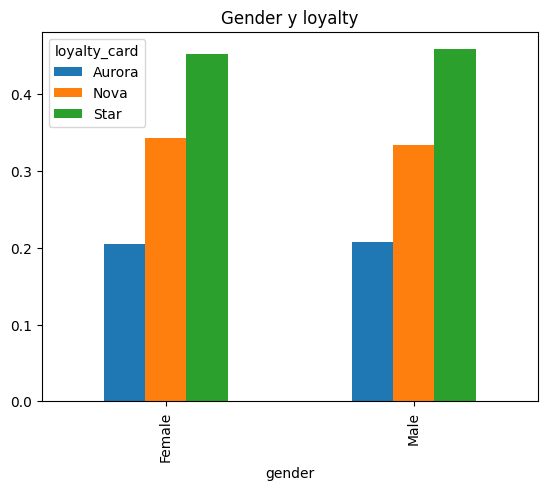

In [44]:
pd.crosstab(df_unido["gender"], df_unido["loyalty_card"], normalize="index").plot(kind="bar")
plt.title("Gender y loyalty")
plt.show()

In [40]:
df_cat["enrollment_type"].value_counts(normalize=True) * 100

enrollment_type
Standard          94.219091
2018 Promotion     5.780909
Name: proportion, dtype: float64

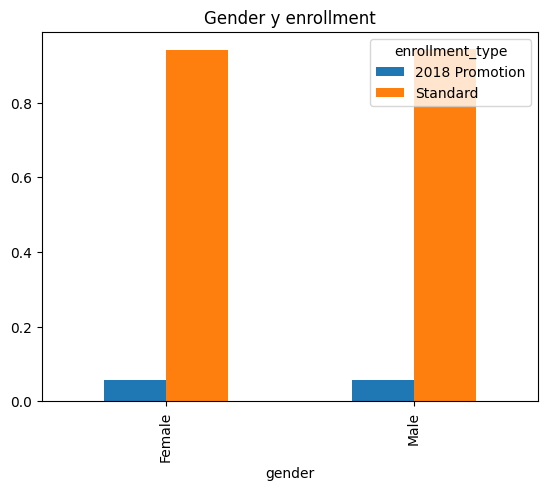

In [45]:
pd.crosstab(df_unido["gender"], df_unido["enrollment_type"], normalize="index").plot(kind="bar")
plt.title("Gender y enrollment")
plt.show()

In [33]:
pd.crosstab(df_unido["gender"], df_unido["status_client"], normalize="index")*100

status_client,Activo,Inactivo
gender,,
Female,87.495869,12.504131
Male,87.912121,12.087879


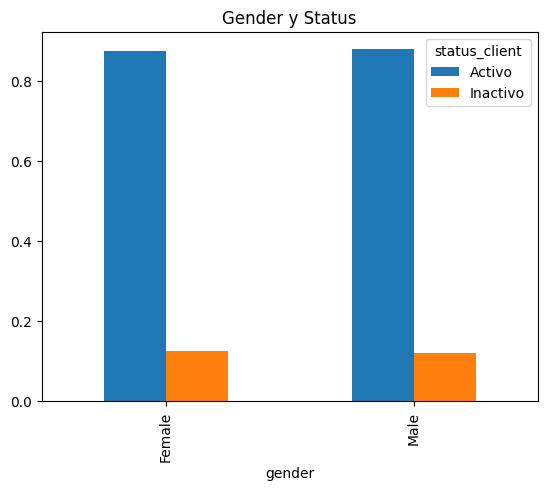

In [34]:
pd.crosstab(df_unido["gender"], df_unido["status_client"], normalize="index").plot(kind="bar")
plt.title("Gender y Status")
plt.show()

In [26]:
pd.crosstab(df_unido["marital_status"], df_unido["status_client"], normalize="index")*100

status_client,Activo,Inactivo
marital_status,,
Divorced,88.482933,11.517067
Married,87.581596,12.418404
Single,87.528779,12.471221


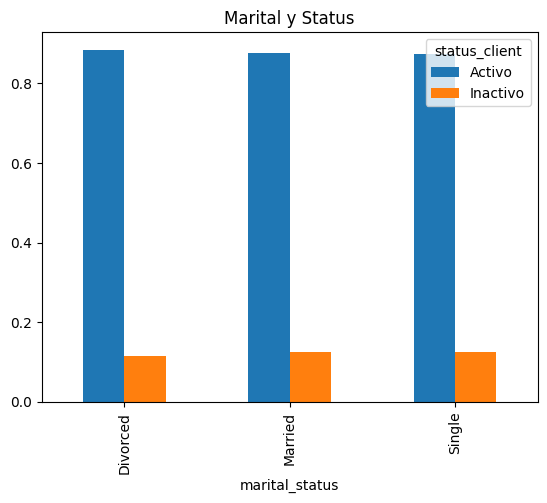

In [35]:
pd.crosstab(df_unido["marital_status"], df_unido["status_client"], normalize="index").plot(kind="bar")
plt.title("Marital y Status")
plt.show()